In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshgupta995/plaaccee/placement (1).csv


In [5]:
df = pd.read_csv('/kaggle/input/datasets/harshgupta995/plaaccee/placement (1).csv')

In [6]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [7]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()

In [11]:
lr.fit(x_train,y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(x_test)

In [16]:
y_pred

array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

In [17]:
y_test.values

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15])

In [18]:
import matplotlib.pyplot as plt

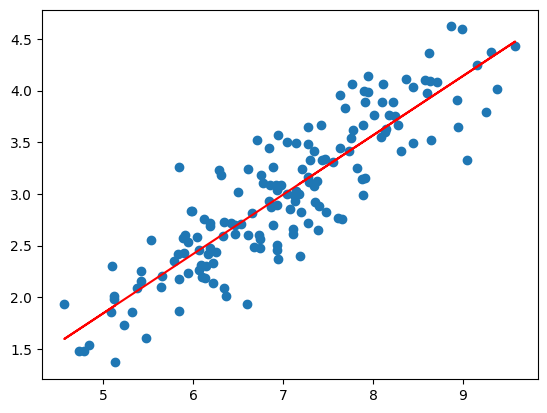

In [23]:
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train),color = 'red')

In [24]:
from sklearn.metrics import r2_score,root_mean_squared_error,mean_squared_error,mean_absolute_error

In [25]:
mean_absolute_error(y_pred,y_test)

0.23150985393278373

In [26]:
mean_squared_error(y_pred,y_test)

0.08417638361329656

In [27]:
root_mean_squared_error(y_pred,y_test)

0.2901316659954521

In [29]:
r2 = r2_score(y_pred,y_test)
r2

0.733797338294438

In [33]:
x_test.shape 

(40, 1)

In [34]:
1 - ((1-r2)*(40-1))/(40-1-1)

0.7267920050916601

Adding a random columns which is not releated to target columns

In [43]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.569696,3.26
1,5.12,0.337367,1.98
2,7.82,0.853059,3.25
3,7.42,0.331333,3.67
4,6.94,0.574371,3.57


Text(0, 0.5, 'Package(in lpa)')

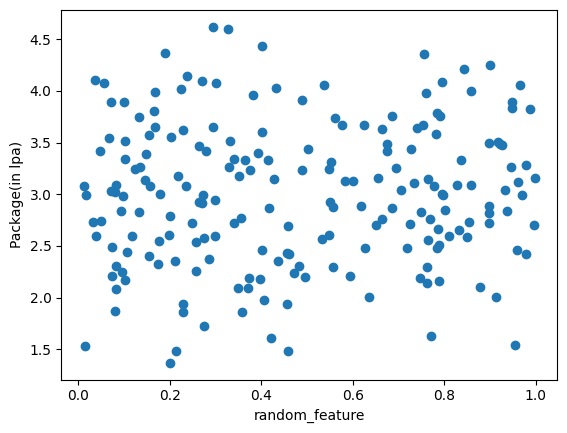

In [36]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [44]:
x = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
mean_absolute_error()

In [47]:
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [53]:
r2 = r2_score(y_pred,y_test)
r2

0.7343992047756005

In [55]:
x_test.shape

(40, 2)

In [54]:
1 - ((1-r2)*(40-1))/(40-1-2)

0.7200424050337411